<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:#CFE8FF;      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">

  <!-- logo sin cambios -->
  <img src="data/imgs/logo.png" align="right" width="200" alt="Logo">

  <!-- Datathon sin cambios -->
  <font color="#1874CD"><h1 align="left" style="margin-top:0;"><b>Datathon PDS06</b></h1></font>

  <!-- Resto en azul oscuro -->
  <h2 align="left" style="color:#003366;margin:0;"><b>Christian Esteve Orts</b></h2>
  <h3 align="left" style="color:#003366;margin:0;">Notebook: regresión lineal</h3>
</div>

<hr>


El ejercicio consta de un problema de regresión, siendo la última columna el target y el resto las potenciales variables predictoras.


<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h2 align="left" style="color:#003366;margin:0;"><b>Librerías</b></h2>
</div>

In [23]:
# Gestión de la estrucutra de los datos
import pandas as pd
import numpy as np

# Gestión de ruta al dataset, por si se necesita cambiar en un futuro a una base de datos o servicio en la nube
from pathlib import Path

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# EDA
# Para test normalidad y distribución normal
from scipy import stats  # Para test de normalidad saphiro-wilk

# Para dividir el dataset en train y test
from sklearn.model_selection import train_test_split

#Preprocesado de datos
from sklearn.preprocessing import StandardScaler
from scipy.stats import boxcox, yeojohnson
#importacion de la funcion de transformación
from Transformacion import FitTransformColumn


# Statsmodels. Para poder usar notación de fórmula y notación de sklearn
import statsmodels.api as sm

# Para test homocedasticidad
from statsmodels.stats.diagnostic import het_breuschpagan

# Para test colinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Evaluación de los modelos
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.impute import SimpleImputer

# Consolidación de del modelo
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder, FunctionTransformer

# Pipelines
from sklearn.pipeline import Pipeline

#modelos
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor


# Utilidades para auditar
from auditoria import audit_pair, missing_report


#Para el PIPELINE
from sklearn.compose import ColumnTransformer
import joblib



<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h2 align="left" style="color:#003366;margin:0;"><b>Establecimiento de random_state para el proyecto</b></h2>
</div>


In [24]:
# Instanciamos un random_state para todo el proyecto

RANDOM_STATE = 42

<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h2 align="left" style="color:#003366;margin:0;"><b>Importación del dataset y comprobación rápida</b></h2>
</div>


In [25]:

DATA_PATH = Path("data/train.xlsx") 
df = pd.read_excel(DATA_PATH)
print(f"Número de observaciones y columnas: {df.shape}")
df.head(10)

Número de observaciones y columnas: (772, 11)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,deseada
0,27585.8881,0.00,2.215558,176.46,4.49,1058.60,780.09,28.0,-1.867265,0.900023,21.539230
1,45693.3376,98.06,1.406881,NaN,6.65,1066.00,785.52,NaN,0.633919,0.862797,17.836744
2,110889.0000,0.00,0.000000,192.00,NaN,931.20,842.60,7.0,-0.203045,0.461557,23.404952
3,241081.0000,26.00,2.093422,210.00,3.93,882.00,699.00,28.0,-1.382800,0.338268,55.551081
4,34670.4400,124.10,0.000000,185.70,0.00,1083.40,NaN,28.0,-0.510016,0.603488,17.596806
5,NaN,NaN,NaN,221.40,10.50,819.20,778.40,28.0,-1.280304,0.634104,31.420111
6,62500.0000,0.00,1.985382,187.42,NaN,956.86,861.17,3.0,0.404982,0.404319,13.817099
7,133956.0000,187.00,0.000000,191.30,6.60,824.30,756.90,NaN,NaN,0.071008,65.909079
8,99225.0000,137.00,0.000000,145.00,5.90,1130.00,NaN,28.0,-0.599393,0.239180,81.751169
9,98156.8900,262.20,0.000000,175.50,8.60,1046.90,611.80,3.0,1.538037,NaN,28.799413


Comprobación rápida de datos faltantes


In [26]:
# NAs
df.isna().sum().sum()

np.int64(774)

Se puede observar de forma rápida que el dataset tiene datos faltantes


In [27]:
# Obtenemos algunos estadísticos para ver la estructura de los datos para situar los datos faltantes
print(f"Recordar el número de observaciones: {df.shape[0]}")

# T es para transponer la matriz y mejorar la legibilidad
display(df.describe().T)

Recordar el número de observaciones: 772


,count,mean,std,min,25%,50%,75%,max
x1,706.0,92761.097733,68338.519818,10404.000000,37900.302400,76729.000000,131478.760000,291600.000000
x2,685.0,72.037898,86.135309,0.000000,0.000000,20.000000,141.300000,359.400000
x3,703.0,0.882659,1.026148,0.000000,0.000000,0.000000,2.073865,2.292256
x4,690.0,181.944594,21.474526,121.750000,164.925000,185.700000,192.000000,247.000000
x5,698.0,6.168636,6.033556,0.000000,0.000000,6.000000,10.100000,32.200000
x6,704.0,971.787997,79.482087,801.000000,932.000000,967.040000,1034.250000,1145.000000
x7,699.0,772.917167,81.459988,594.000000,725.950000,779.700000,824.000000,992.600000
x8,687.0,45.914119,62.163402,1.000000,14.000000,28.000000,56.000000,365.000000
x9,694.0,0.018116,0.979987,-3.241267,-0.651777,0.046709,0.654966,2.720169
x10,680.0,0.496178,0.287545,0.005230,0.248967,0.497494,0.731890,0.998348


Comparando la columna [mean] con el 50% las variables x4,x6, x7 y x10 parecen tener las mejores distribuciones. También la deseada.


Si comparamos el total de registros [count] de la columna target "deseada" con las variables predictoras, se puede comprobar que hay datos faltantes en todas las variables.


<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h2 align="left" style="color:#003366;margin:0;"><b>Análisis exploratorio de los datos</b></h2>
</div>


### Gráfico de distribución para cada variable numérica


Text(0.5, 0.98, 'Distribución de variables numéricas')

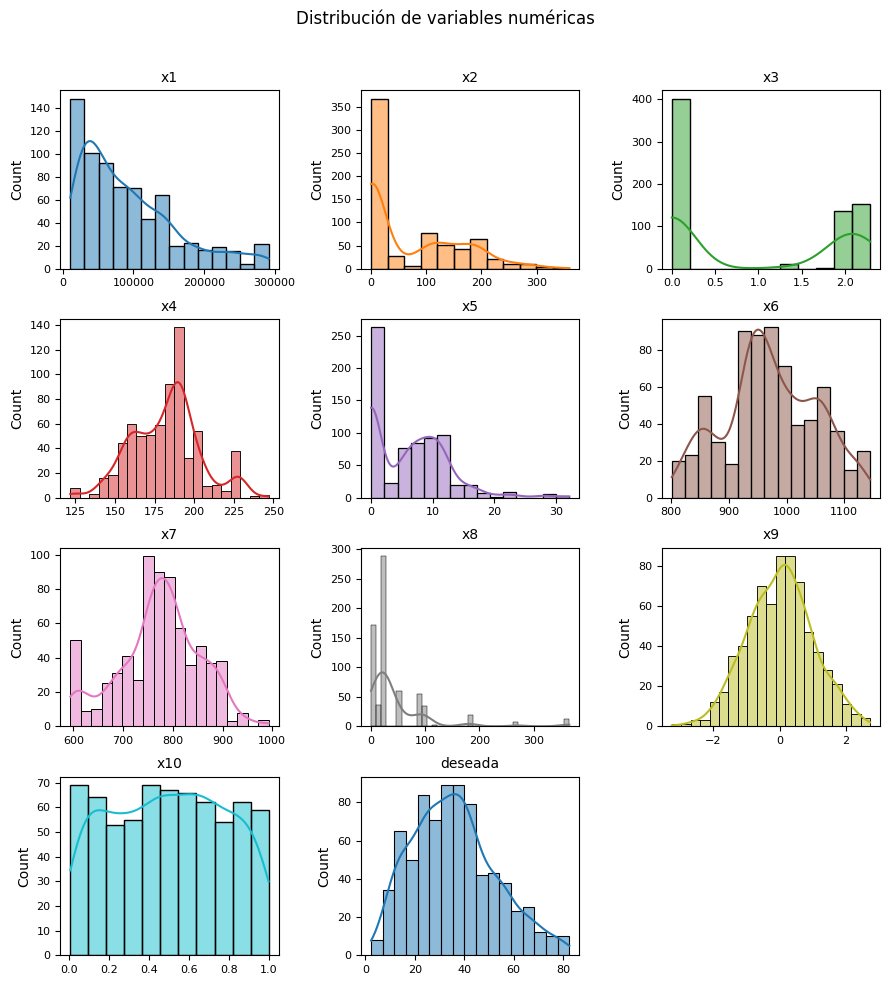

In [28]:
# Repasar los comentarios del código y cambiarlos a mejoras expositivas

import math  # Para calcular el número de filas necesarias


# --- Selección de variables y dimensionado del lienzo ---

columnas_numeric = df.select_dtypes(include=np.number).columns
n_vars = len(columnas_numeric)
if n_vars == 0:
    raise ValueError("El DataFrame no contiene columnas numéricas.")

# Máximo de columnas de subplots por fila (ajustable cambiando esta variable)
ncols = 3
# Filas necesarias para cubrir todas las variables
nrows = math.ceil(n_vars / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(3*ncols, 2.5*nrows))

# Convertir a array 1D para indexar sin errores, incluso si hay una sola fila/columna
axes = np.atleast_1d(axes).ravel()

# Paleta de colores (rotará si hay más variables que colores)
palette = sns.color_palette(n_colors=max(n_vars, 6))

# --- Bucle de trazado: un histograma por variable numérica ---
for i, col in enumerate(columnas_numeric):
    ax = axes[i]
    sns.histplot(
        data=df, x=col, stat="count", kde=True,
        color=palette[i % len(palette)], ax=ax
    )
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_xlabel("")

# --- Ocultar ejes no usados (si la rejilla quedó más grande de lo necesario) ---
for ax in axes[n_vars:]:
    ax.set_visible(False)

# --- Ajustes finales de maquetación ---
fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Distribución de variables numéricas', fontsize=12)

Según las gráficas , las variables x4, x6, x7 y x9 tienen las mejores distribuciones. La columna a predecir [deseada] tiene una buena distribución.


### Test de Saphiro

Para


In [29]:
# Normalidad en la variable respuesta "deseada"

shapiro_test = stats.shapiro(df["deseada"])
print(
    f"Test Shapiro-Wilk: estadístico = {shapiro_test[0]}, p-value = {shapiro_test[1]}")

Test Shapiro-Wilk: estadístico = 0.977448345500092, p-value = 1.538592711759505e-09


El test Shapiro-Wilk contrasta la hipótesis nula de distribución normal de los datos. La variable respuesta [deseada] obtenemos un p-valor superior a 0,05 (nivel de confianza de un 95%) y, por lo tanto, podemos aceptar la hipótesis nula y asumir que la distrubución es normal.


### Correlaciones


Generamos la matriz directamente, ya que la visualización es mejor.


<Axes: >

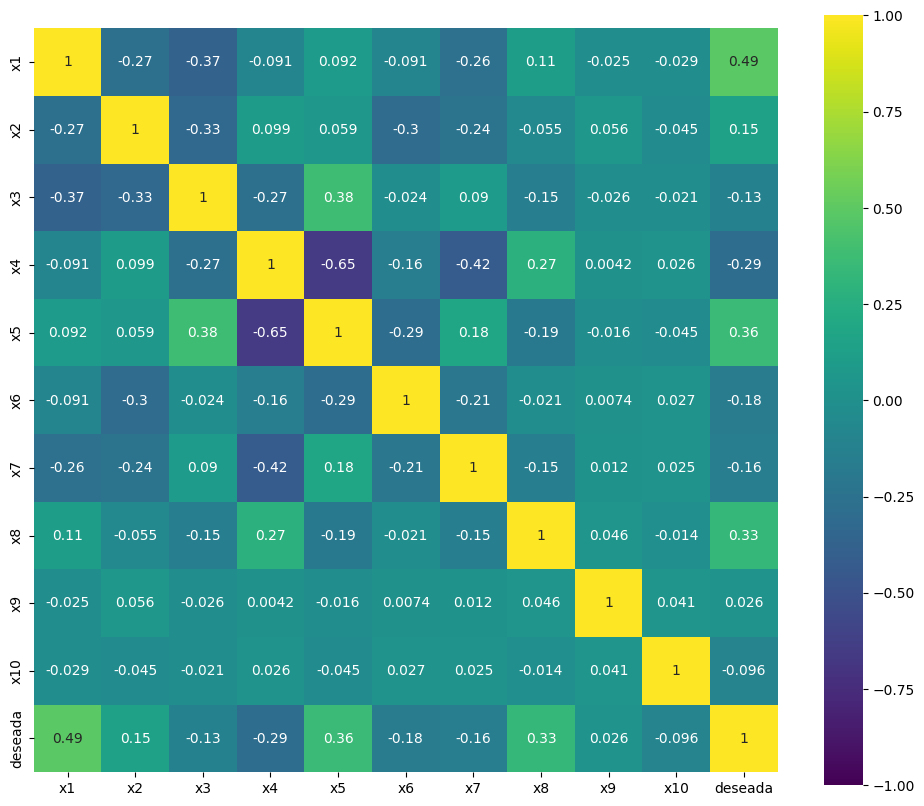

In [30]:
# Matriz de correlaciones entre variables numéricas
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(),
            cmap="viridis",
            vmin=-1, vmax=1,  # Evitamos el cálculo automático de los límites
            annot=True,
            cbar=True,
            square=True)

Conclusión: x1 es el predictor lineal más potente; x5, x8 y x4 (con signo opuesto) aportan información adicional. El resto apenas correlaciona linealmente con la respuesta.

La matriz revela que x1 es el predictor lineal dominante (ρ ≈ 0.49) seguido de x5 y x8; x4 ejerce un efecto inverso (ρ ≈ -0.29).

La única colinealidad preocupante es el fuerte anticorrelación x4-x5 (-0.65). Por ello, vigilaré VIF o usaré regularización para evitar inestabilidad en un modelo lineal. En cambio, un modelo basado en árboles manejaría bien estas correlaciones moderadas.


### Distribución de cada variable enfrentada al resto


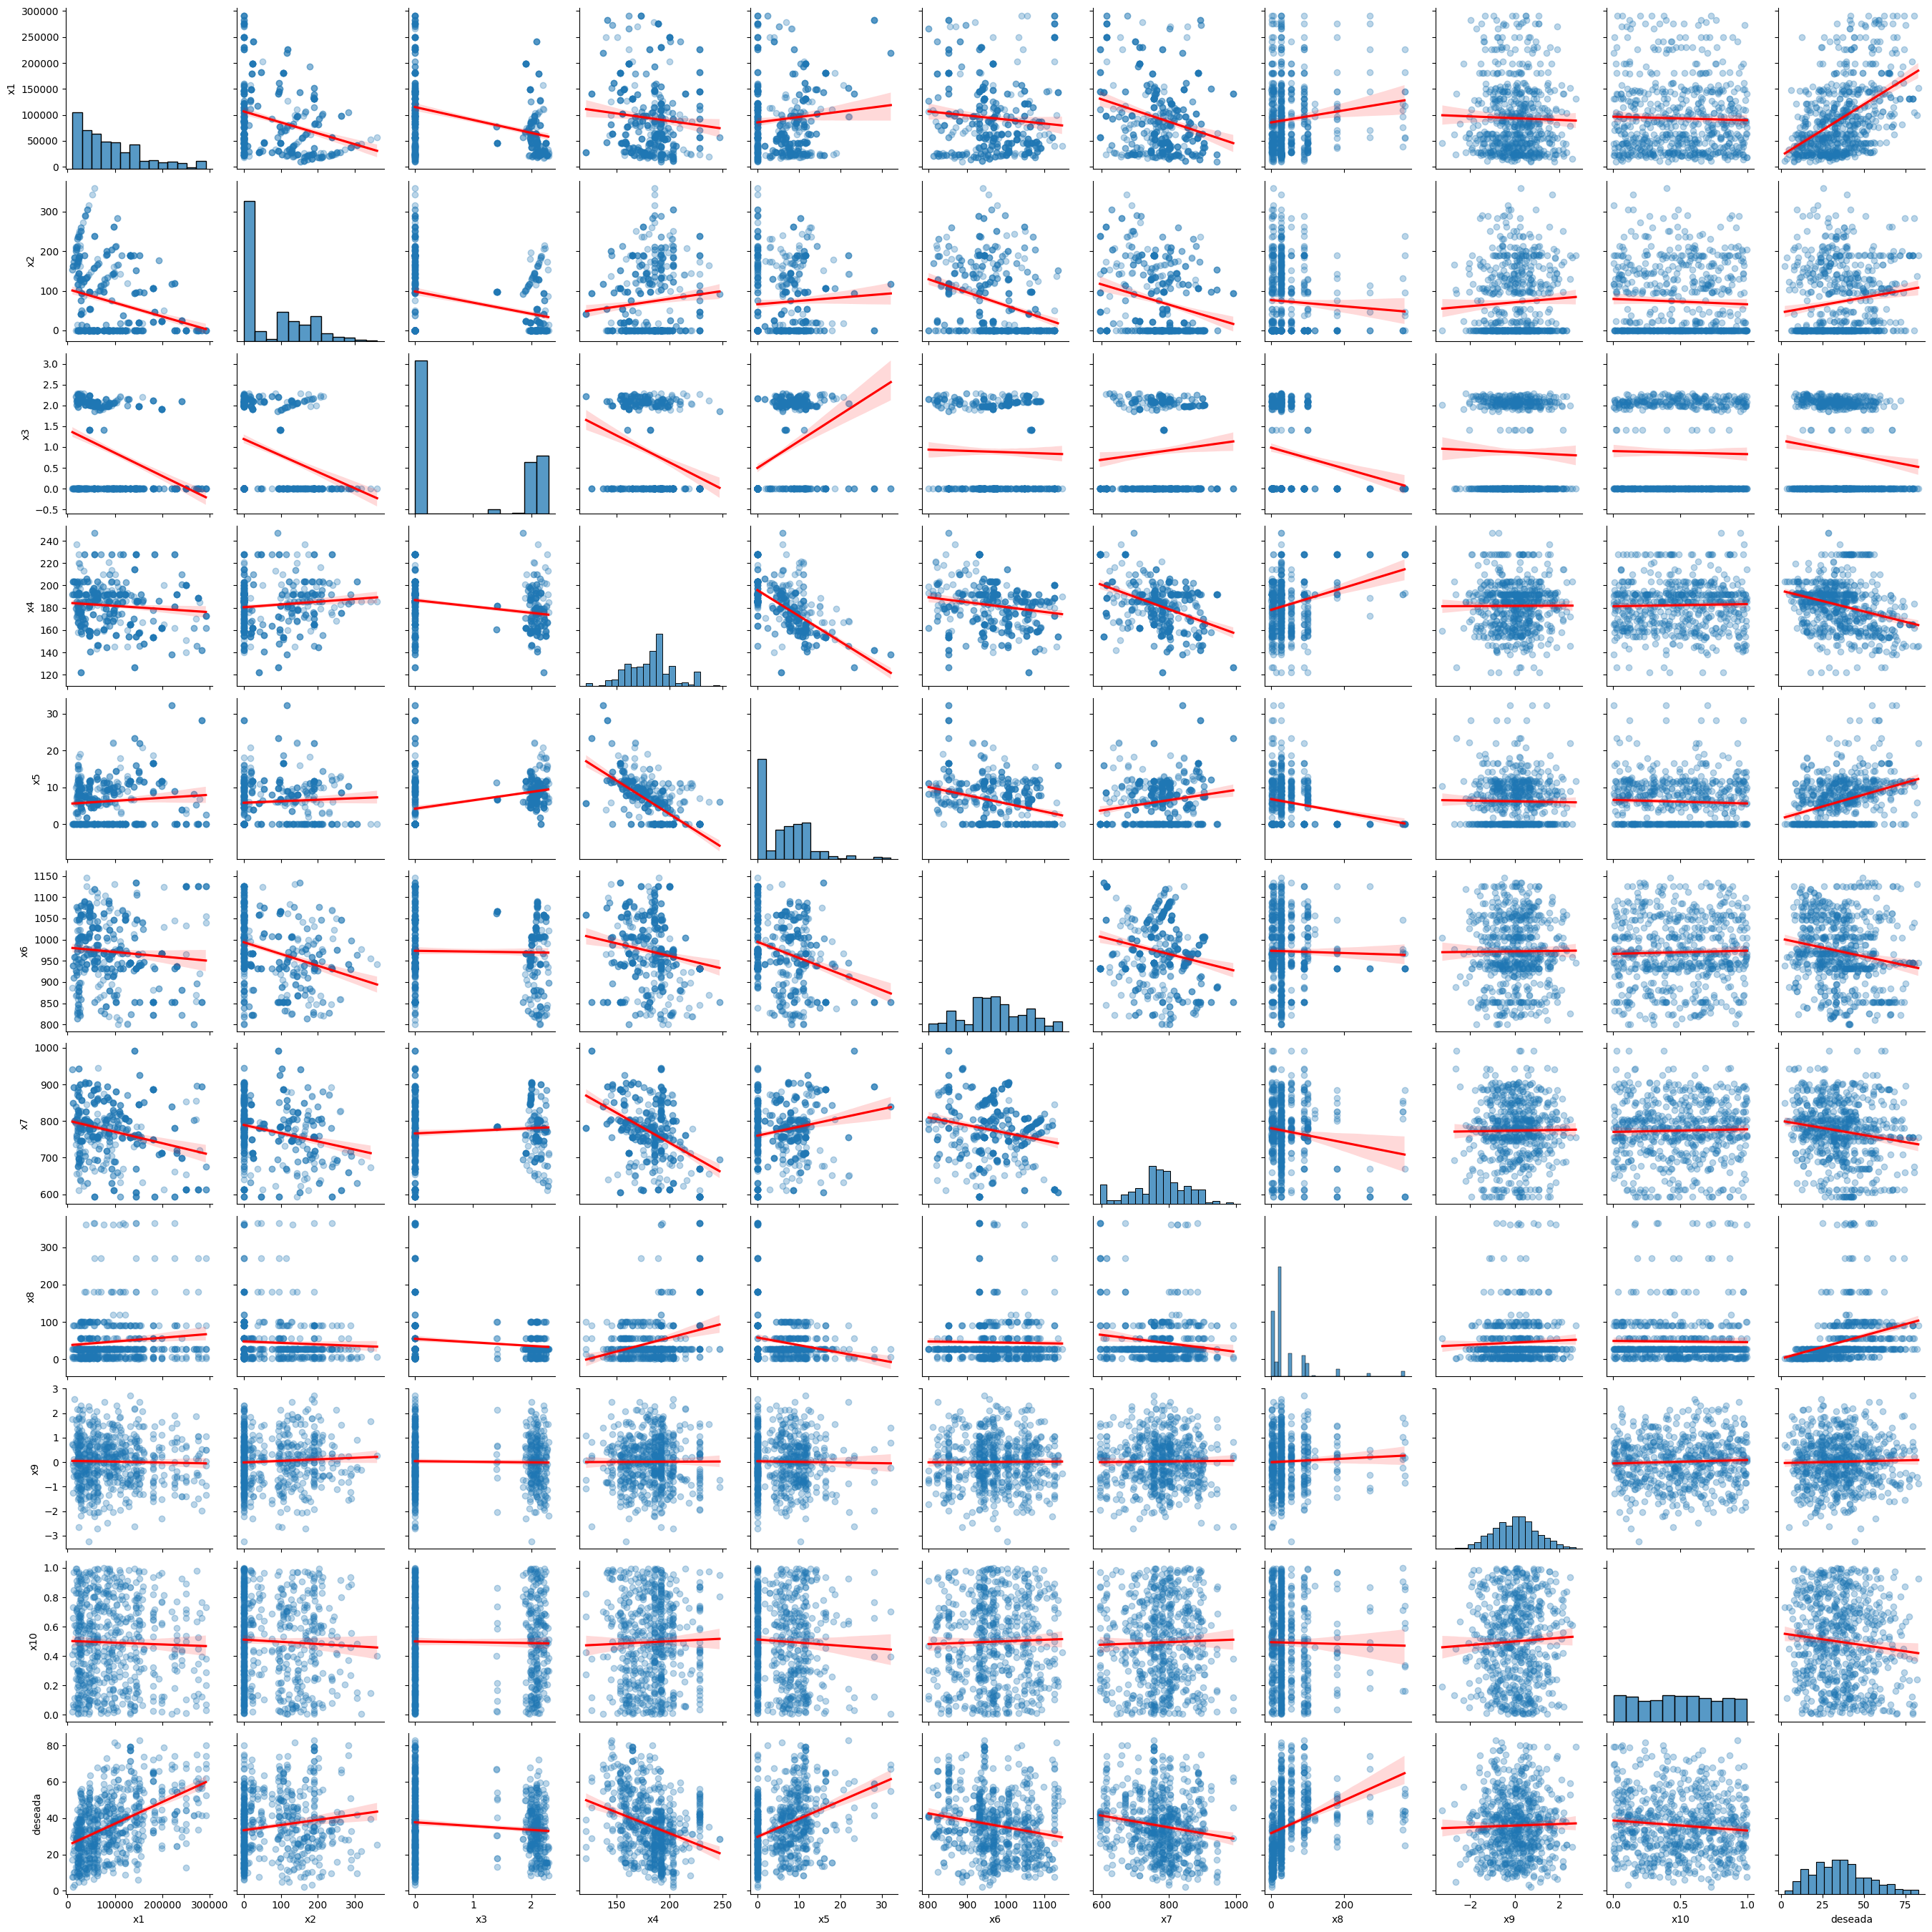

In [31]:


# Distribución de cada variable enfrentada al resto
sns.pairplot(df, kind="reg",
             plot_kws={"line_kws": {"color": "red"},
                       "scatter_kws": {"alpha": 0.3}})

plt.show()

Tendencias lineales claras con el target: x1, x5, x8 (positivas) x4 (negativa). Refuerza lo se ve en la matriz de correlación: serán los predictores más prometedores.

Relación negativa marcada entre predictores x4 ↔ x5 Evidencia visual de su colinealidad moderada (r ≈ −0,65). Conviene monitorizar VIF o usar regularización.

Escalas muy dispares, por ejemplo x1 y x9. Será necesario la normalización de las variables predictoras.

Las distribucuines de cola pesada de x1 (potancialmente el predictor principal), x2 y x5 son susceptibles de necesitar transformación por BosCox o Yeo-Johnson.

x9 y, en menor medida, x10 (todas las dispersión–[deseada] son nubes sin patrón)

x3 es pobre en colinealidad y presenta una gran cantidad de valores en 0, por lo que es candidata a excluirse.



<div class = "alert alert-success" style = "border-radius:10px;border-width:3px;border-color:darkgreen;font-family:Verdana,sans-serif;font-size:16px;"> Descartar x9: De entrada (r ≈ +0,03, señal prácticamente nula en un modelo lineal sin interacciones).
</div> 

<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h2 align="left" style="color:#003366;margin:0;"><b>División del dataset</b></h2>
</div>


In [32]:
# # División en entrenamiento y test
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)



# Ahora dividimos en X e y
# Dataframe entrenamiento con la variable respuesta
y_train = df_train["deseada"].copy()
y_test  = df_test["deseada"].copy() # Dataframe test con la variable respuesta

#Dataframe entrenamiento con las variables predictoras
X_train = df_train.drop(columns=["deseada"]).copy()
X_test  = df_test.drop(columns=["deseada"]).copy() #Dataframe test con las variables predictoras



# Comprobamos dimensiones
print(f"Dimensiones train: {X_train.shape}.")
print(f"Dimensiones test: {X_test.shape}.")

Dimensiones train: (617, 10).
Dimensiones test: (155, 10).


<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h2 align="left" style="color:#003366;margin:0;"><b>Transformación de los datos</b></h2>
</div>


<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h3 align="left" style="color:#003366;margin:0;"><b>Creación de diferentes escenarios de dataframe para la prueba de los modelos. </b></h3>
<h5 align="left" style="color:#003366;margin:0;"><b>Ante los resultados del análisis exploratorio de los datos, es probable que los modelos basados en árboles sean la mejor opción, por lo que se van a crear difentes escenarios de dataset que acoplen mejor en cada tipo de modelo a probar y evaluar cuál es el que mejor resultaod ofrece.<b><h5>
</div>


# Escenario 1

In [33]:
# =========================
# Guardamos una copia CRUDA de x8 (para dummies más adelante)
x8_train_raw = X_train['x8'].copy()
x8_test_raw  = X_test['x8'].copy()



# =========================
# Escenario 1 — crudo (sin x9)
# =========================

esc1_train = X_train.copy()
esc1_test  = X_test.copy()

esc1_train = X_train.drop(columns=['x9']).copy()
esc1_test  = X_test.drop(columns=['x9']).copy()


# Escenario 2

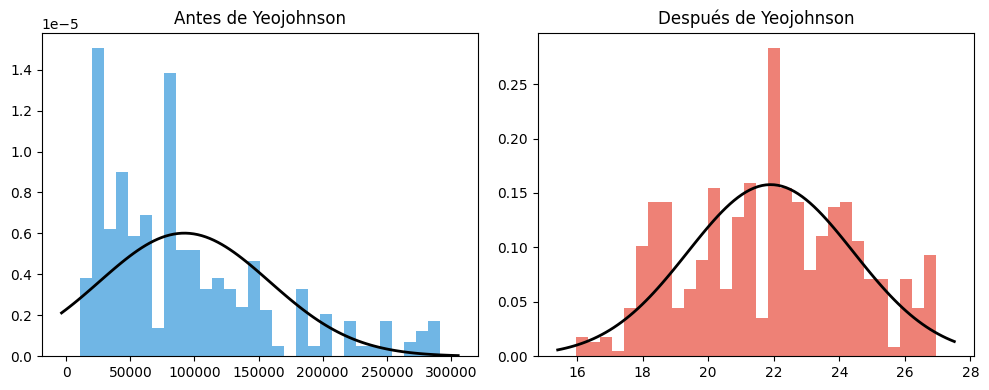

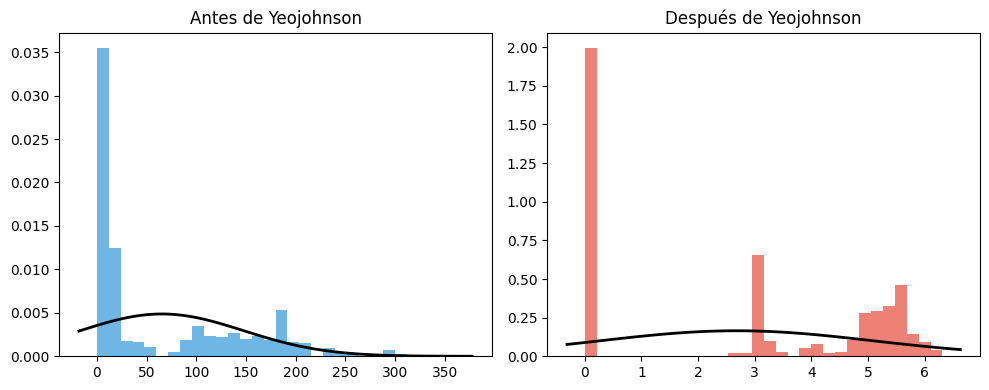

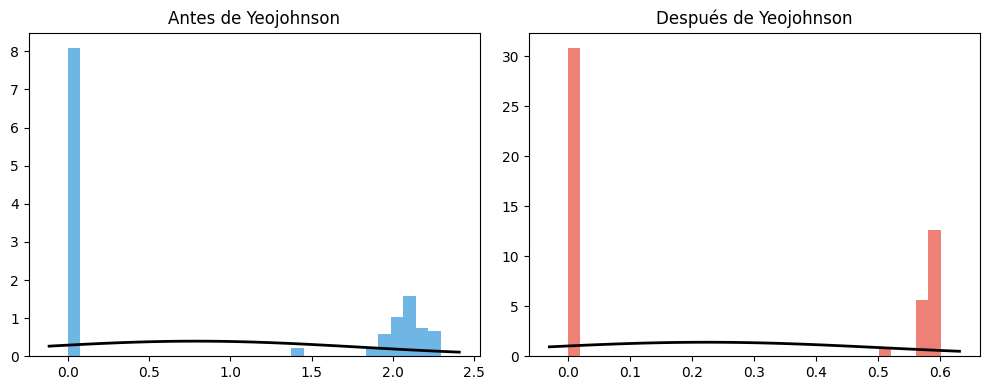

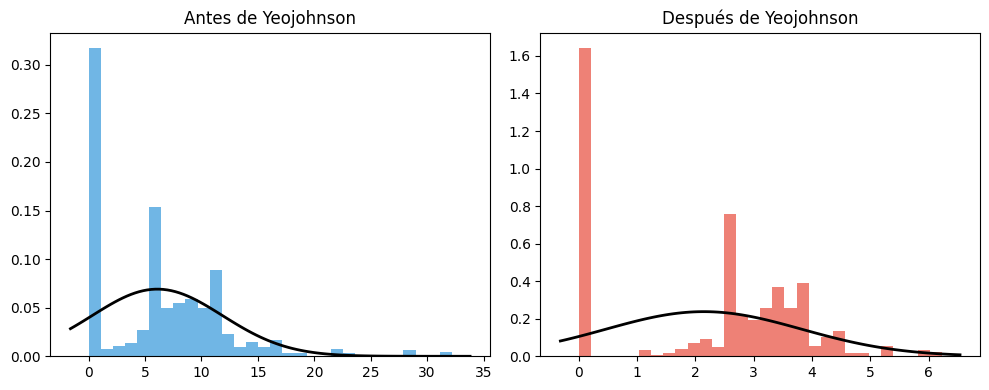

Escenario 2 OK: continuas imputadas y transformadas; x8 intacta.
Lambdas YJ → x1:0.1089 | x2:0.0237 | x3:-1.3156 | x5:0.3018


In [34]:

# =========================
# Escenario 2 — imputación + Yeo-Johnson (solo continuas; NO tocar x8)
# =========================
# ============= ESCENARIO 2 (IMPUTACIÓN + YEO-JOHNSON) =============
# Nota: x8 (categórica) no se toca en Esc2.



esc2_train = esc1_train.copy()
esc2_test  = esc1_test.copy()

# ---------- IMPUTACIÓN MEDIANA (continuas) ----------
# x1
_imp_x1 = SimpleImputer(strategy='median')
esc2_train['x1'] = _imp_x1.fit_transform(esc2_train[['x1']]).ravel()
esc2_test['x1']  = _imp_x1.transform(esc2_test[['x1']]).ravel()

# x2
_imp_x2 = SimpleImputer(strategy='median')
esc2_train['x2'] = _imp_x2.fit_transform(esc2_train[['x2']]).ravel()
esc2_test['x2']  = _imp_x2.transform(esc2_test[['x2']]).ravel()

# x3
_imp_x3 = SimpleImputer(strategy='median')
esc2_train['x3'] = _imp_x3.fit_transform(esc2_train[['x3']]).ravel()
esc2_test['x3']  = _imp_x3.transform(esc2_test[['x3']]).ravel()

# x4
_imp_x4 = SimpleImputer(strategy='median')
esc2_train['x4'] = _imp_x4.fit_transform(esc2_train[['x4']]).ravel()
esc2_test['x4']  = _imp_x4.transform(esc2_test[['x4']]).ravel()

# x5
_imp_x5 = SimpleImputer(strategy='median')
esc2_train['x5'] = _imp_x5.fit_transform(esc2_train[['x5']]).ravel()
esc2_test['x5']  = _imp_x5.transform(esc2_test[['x5']]).ravel()

# x6
_imp_x6 = SimpleImputer(strategy='median')
esc2_train['x6'] = _imp_x6.fit_transform(esc2_train[['x6']]).ravel()
esc2_test['x6']  = _imp_x6.transform(esc2_test[['x6']]).ravel()

# x7
_imp_x7 = SimpleImputer(strategy='median')
esc2_train['x7'] = _imp_x7.fit_transform(esc2_train[['x7']]).ravel()
esc2_test['x7']  = _imp_x7.transform(esc2_test[['x7']]).ravel()

# x10
_imp_x10 = SimpleImputer(strategy='median')
esc2_train['x10'] = _imp_x10.fit_transform(esc2_train[['x10']]).ravel()
esc2_test['x10']  = _imp_x10.transform(esc2_test[['x10']]).ravel()

# ---------- YEO-JOHNSON SOLO EN x1, x2, x3, x5 ----------
# Usamos la funcion FitTrnasformaColumn para AJUSTAR en TRAIN (devuelve columna transformada + lambda)


# x1
esc2_train['x1'], lam_x1 = FitTransformColumn(esc2_train['x1'].values, method='yeojohnson')
esc2_test['x1'] = yeojohnson(esc2_test['x1'].values, lmbda=lam_x1)

# x2
esc2_train['x2'], lam_x2 = FitTransformColumn(esc2_train['x2'].values, method='yeojohnson')
esc2_test['x2'] = yeojohnson(esc2_test['x2'].values, lmbda=lam_x2)

# x3
esc2_train['x3'], lam_x3 = FitTransformColumn(esc2_train['x3'].values, method='yeojohnson')
esc2_test['x3'] = yeojohnson(esc2_test['x3'].values, lmbda=lam_x3)

# x5
esc2_train['x5'], lam_x5 = FitTransformColumn(esc2_train['x5'].values, method='yeojohnson')
esc2_test['x5'] = yeojohnson(esc2_test['x5'].values, lmbda=lam_x5)

# ---------- Comprobación rápida ----------
_cols_cont = ['x1','x2','x3','x4','x5','x6','x7','x10']
assert not np.isnan(esc2_train[_cols_cont].values).any(), "NaN en continuas TRAIN (Esc2)"
assert not np.isnan(esc2_test[_cols_cont].values).any(),  "NaN en continuas TEST  (Esc2)"
print("Escenario 2 OK: continuas imputadas y transformadas; x8 intacta.")
print(f"Lambdas YJ → x1:{lam_x1:.4f} | x2:{lam_x2:.4f} | x3:{lam_x3:.4f} | x5:{lam_x5:.4f}")




# Escenario 3 Escalado

In [35]:
# ============= ESCENARIO 3 (ESCALADO) =============
from sklearn.preprocessing import StandardScaler
import numpy as np

# Partimos del Escenario 2 (ya imputado + YJ en x1,x2,x3,x5)
esc3_train = esc2_train.copy()
esc3_test  = esc2_test.copy()

# Creamos un scaler POR COLUMNA para máxima trazabilidad
sc_x1  = StandardScaler()
sc_x2  = StandardScaler()
sc_x3  = StandardScaler()
sc_x4  = StandardScaler()
sc_x5  = StandardScaler()
sc_x6  = StandardScaler()
sc_x7  = StandardScaler()
sc_x10 = StandardScaler()

# Ajuste en TRAIN y transformación en TRAIN/TEST (columna a columna)
esc3_train['x1']  = sc_x1.fit_transform( esc2_train[['x1']] ).ravel()
esc3_test['x1']   = sc_x1.transform(      esc2_test[['x1']]  ).ravel()

esc3_train['x2']  = sc_x2.fit_transform( esc2_train[['x2']] ).ravel()
esc3_test['x2']   = sc_x2.transform(      esc2_test[['x2']]  ).ravel()

esc3_train['x3']  = sc_x3.fit_transform( esc2_train[['x3']] ).ravel()
esc3_test['x3']   = sc_x3.transform(      esc2_test[['x3']]  ).ravel()

esc3_train['x4']  = sc_x4.fit_transform( esc2_train[['x4']] ).ravel()
esc3_test['x4']   = sc_x4.transform(      esc2_test[['x4']]  ).ravel()

esc3_train['x5']  = sc_x5.fit_transform( esc2_train[['x5']] ).ravel()
esc3_test['x5']   = sc_x5.transform(      esc2_test[['x5']]  ).ravel()

esc3_train['x6']  = sc_x6.fit_transform( esc2_train[['x6']] ).ravel()
esc3_test['x6']   = sc_x6.transform(      esc2_test[['x6']]  ).ravel()

esc3_train['x7']  = sc_x7.fit_transform( esc2_train[['x7']] ).ravel()
esc3_test['x7']   = sc_x7.transform(      esc2_test[['x7']]  ).ravel()

esc3_train['x10'] = sc_x10.fit_transform(esc2_train[['x10']]).ravel()
esc3_test['x10']  = sc_x10.transform(     esc2_test[['x10']] ).ravel()

# NOTA: x8 NO se escala (es categórica y la trataremos en Escenario 4 con dummies)

# ---- Reporte de escalado para exposición (media y escala aprendidas en TRAIN) ----
scalers = {
    'x1': sc_x1, 'x2': sc_x2, 'x3': sc_x3, 'x4': sc_x4,
    'x5': sc_x5, 'x6': sc_x6, 'x7': sc_x7, 'x10': sc_x10
}
print("Parámetros de escalado (aprendidos en TRAIN):")
for col, sc in scalers.items():
    print(f"  {col}: mean_={sc.mean_[0]:.6f} | scale_={sc.scale_[0]:.6f}")

# ---- Chequeo: en TRAIN las continuas deben quedar ~N(0,1) ----
_cols_cont = ['x1','x2','x3','x4','x5','x6','x7','x10']
max_abs_mean = float(np.abs(esc3_train[_cols_cont].mean()).max())
max_std_dev  = float(np.abs(esc3_train[_cols_cont].std(ddof=0) - 1).max())  # ddof=0 para ser coherentes con StandardScaler
print(f"\nChequeo TRAIN post-escalado → max|media|={max_abs_mean:.4e}, max|std-1|={max_std_dev:.4e}")

# ---- Auditoría (NaN permitidos solo en x8; el resto deben estar limpios) ----
audit_pair(esc3_train, esc3_test, "Escenario 3", allow_nans_cols=['x8'])


Parámetros de escalado (aprendidos en TRAIN):
  x1: mean_=21.902330 | scale_=2.530334
  x2: mean_=2.680395 | scale_=2.415985
  x3: mean_=0.223577 | scale_=0.284230
  x4: mean_=182.741864 | scale_=19.981118
  x5: mean_=2.144747 | scale_=1.677838
  x6: mean_=971.618849 | scale_=76.168617
  x7: mean_=774.038768 | scale_=76.639712
  x10: mean_=0.511143 | scale_=0.271549

Chequeo TRAIN post-escalado → max|media|=8.4715e-16, max|std-1|=1.1102e-16
[OK] Escenario 3: (617, 9) / (155, 9) (columnas alineadas; NaN solo en ['x8'])


True

# Escenario 4 Dummies de x8

In [36]:
# ============= ESCENARIO 4 (DUMMIES DE x8, ESTILO CURSO) =============
import pandas as pd

# Partimos del Escenario 3 (continuas escaladas; x8 intacta)
esc4_train = esc3_train.copy()
esc4_test  = esc3_test.copy()

# 1) Limpiamos x8 -> 'x8_cat' (solo etiquetas) desde el valor CRUDO
#    - Soporte para strings como "28", "28.0", "28 días" → extraemos el número
#    - Convertimos a entero "nullable" para conservar faltantes
#    - Pasamos a string y hacemos explícito 'Missing' como categoría
def preparar_x8_como_etiqueta(serie):
    s_num = pd.to_numeric(serie.astype(str).str.extract(r'(\d+)', expand=False), errors='coerce')
    s_int = s_num.astype('Int64')
    return s_int.astype('string').fillna('Missing')

# OJO: usamos x8 de Escenario 3 (no transformamos x8 en Esc2/Esc3), por lo que sigue siendo "cruda"
esc4_train['x8_cat'] = preparar_x8_como_etiqueta(x8_train_raw) # Usamos x8 cruda que se guardó antes
esc4_test['x8_cat']  = preparar_x8_como_etiqueta(x8_test_raw) # Usamos x8 cruda que se guardó antes

print("Categorías de x8 (TRAIN), tras limpieza:")
print(esc4_train['x8_cat'].value_counts(dropna=False).sort_index())

# 2) Creamos variables dummy con el MISMO estilo del curso:
#    df = pd.get_dummies(df, columns=["Zona"], drop_first=True)
#    Aquí:
#    - columns=["x8_cat"]  (la columna categórica recién creada)
#    - drop_first=True     (elimina la categoría base, evita colinealidad)
#    - prefix={"x8_cat":"x8"} para que las columnas resulten x8_*
esc4_train = pd.get_dummies(
    esc4_train,
    columns=["x8_cat"],
    drop_first=True,
    prefix={"x8_cat": "x8"},
    dtype="uint8"
)
esc4_test = pd.get_dummies(
    esc4_test,
    columns=["x8_cat"],
    drop_first=True,
    prefix={"x8_cat": "x8"},
    dtype="uint8"
)

# 3) Eliminamos la columna original x8 (ya está representada por las dummies)
esc4_train = esc4_train.drop(columns=['x8'], errors='ignore')
esc4_test  = esc4_test.drop(columns=['x8'],  errors='ignore')

# 4) Alineamos columnas de TEST con las de TRAIN (por si falta alguna dummy en test)
esc4_test = esc4_test.reindex(columns=esc4_train.columns, fill_value=0)

# 5) Información clara para la exposición
cols_dummies = [c for c in esc4_train.columns if c.startswith('x8_')]
print(f"\nDUMMIES CREADAS (TRAIN): {len(cols_dummies)} columnas")
print(cols_dummies[:10], "..." if len(cols_dummies) > 10 else "")

# 6) Auditoría: desde Escenario 4 no debe quedar ningún NaN
audit_pair(esc4_train, esc4_test, "Escenario 4")




Categorías de x8 (TRAIN), tras limpieza:
x8_cat
1            1
100         27
14          30
180         16
270          6
28         234
3           72
360          4
365          7
56          47
7           62
90          30
91          13
Missing     68
Name: count, dtype: Int64

DUMMIES CREADAS (TRAIN): 13 columnas
['x8_100', 'x8_14', 'x8_180', 'x8_270', 'x8_28', 'x8_3', 'x8_360', 'x8_365', 'x8_56', 'x8_7'] ...
[OK] Escenario 4: (617, 21) / (155, 21) (columnas alineadas; NaN solo en [])


True

# Escenario 5

In [37]:
# ============= ESCENARIO 5 (INTERACCIONES) =============
# Objetivo: añadir un puñado de interacciones útiles sin disparar la dimensionalidad.
# Usamos las continuas ya escaladas de Escenario 3 y las dummies de x8 de Escenario 4.

esc5_train = esc4_train.copy()
esc5_test  = esc4_test.copy()

# 1) Selecciona qué continuas usar en interacciones (expón explícito y simple)
interact_with = ['x3', 'x5']  # Puedes ajustar esta lista si quieres

# 2) Identifica columnas dummies de x8 creadas en Escenario 4
x8_dummy_cols = [c for c in esc4_train.columns if c.startswith('x8_')]
print("\nInteracciones a crear (continuas × dummies):")
print(f"Continuas: {interact_with}")
print(f"Dummies:   {x8_dummy_cols}")

# 3) Crea las interacciones (TRAIN/TEST) de forma clara
num_new_feats = 0
for cnum in interact_with:
    for ccat in x8_dummy_cols:
        newc = f'{cnum}__x_{ccat}'
        # usamos la versión escalada (esc3) para la continua y la dummy de esc4
        esc5_train[newc] = esc3_train[cnum].values * esc4_train[ccat].values
        esc5_test[newc]  = esc3_test[cnum].values  * esc4_test[ccat].values
        num_new_feats += 1

print(f"\nInteracciones añadidas: {num_new_feats}")

# 4) Auditoría final del escenario 5
audit_pair(esc5_train, esc5_test, "Escenario 5")



Interacciones a crear (continuas × dummies):
Continuas: ['x3', 'x5']
Dummies:   ['x8_100', 'x8_14', 'x8_180', 'x8_270', 'x8_28', 'x8_3', 'x8_360', 'x8_365', 'x8_56', 'x8_7', 'x8_90', 'x8_91', 'x8_Missing']

Interacciones añadidas: 26
[OK] Escenario 5: (617, 47) / (155, 47) (columnas alineadas; NaN solo en [])


True

### Comprobación que los valores lambda y median aplicados a los dataframe resultantes son los que corresponden y se ha realizado.
<h3 style="font-family:Verdana,sans-serif; font-size:16px; color:#FF0000;">
    Este código es aportación de la IA 
</h3>



In [38]:
# =========================
# Resumen de preprocesado (medianas, lambdas, escalado y dummies)
# =========================
import pandas as pd
import numpy as np

# 1) Declaramos qué columnas tienen Yeo-Johnson en NUESTRO flujo
HAS_YJ = {
    'x1': True, 'x2': True, 'x3': True, 'x4': False,
    'x5': True, 'x6': False, 'x7': False, 'x8': False,
    'x10': False
}

# 2) Mapas a los objetos reales usados (si alguno no existe, lo manejamos como None)
IMPUTERS = {
    'x1': globals().get('_imp_x1'),
    'x2': globals().get('_imp_x2'),
    'x3': globals().get('_imp_x3'),
    'x4': globals().get('_imp_x4'),
    'x5': globals().get('_imp_x5'),
    'x6': globals().get('_imp_x6'),
    'x7': globals().get('_imp_x7'),
    'x10': globals().get('_imp_x10'),
}
LAMBDAS = {
    'x1': globals().get('lam_x1'),
    'x2': globals().get('lam_x2'),
    'x3': globals().get('lam_x3'),
    'x5': globals().get('lam_x5'),
    # las demás no llevan YJ
}
SCALERS = {
    'x1': globals().get('sc_x1'),
    'x2': globals().get('sc_x2'),
    'x3': globals().get('sc_x3'),
    'x4': globals().get('sc_x4'),
    'x5': globals().get('sc_x5'),
    'x6': globals().get('sc_x6'),
    'x7': globals().get('sc_x7'),
    'x10': globals().get('sc_x10'),
}

def _safe(val, attr, idx=0):
    """Devuelve attr de val si existe; si no, None."""
    if val is None: return None
    try:
        v = getattr(val, attr)
        # casos statistics_ / mean_ / scale_ vienen como arrays
        if isinstance(v, (list, tuple, np.ndarray)):
            return float(v[idx])
        return float(v)
    except Exception:
        return None

rows = []
for var in ['x1','x2','x3','x4','x5','x6','x7','x8','x10']:
    imp = IMPUTERS.get(var)
    sca = SCALERS.get(var)
    has_yj = HAS_YJ.get(var, False)
    lam = LAMBDAS.get(var, None) if has_yj else None

    rows.append({
        "variable": var,
        "imputer_median": _safe(imp, "statistics_"),      # mediana aprendida en TRAIN (Esc2)
        "yj_aplicado": "Sí" if has_yj else "No",          # solo x1,x2,x3,x5
        "lambda_yj": None if not has_yj else (None if lam is None else float(lam)),
        "scaler_mean": _safe(sca, "mean_"),               # media aprendida en TRAIN (Esc3)
        "scaler_scale": _safe(sca, "scale_"),             # desviación aprendida en TRAIN (Esc3)
        "nota": "categórica (se dummifica en Esc4)" if var=="x8" else ""
    })

summary = pd.DataFrame(rows, columns=[
    "variable","imputer_median","yj_aplicado","lambda_yj","scaler_mean","scaler_scale","nota"
])

print("\n=== Resumen de medianas, λ (Yeo-Johnson) y escalado (aprendidos en TRAIN) ===")
print(summary.to_string(index=False))

# 3) Resumen de dummies de x8 creadas en Esc4
x8_dummy_cols = [c for c in esc4_train.columns if c.startswith('x8_')]
print("\n=== Dummies de x8 (Escenario 4) ===")
print(f"Nº dummies (TRAIN): {len(x8_dummy_cols)}")
print("Columnas (primeras 12):", x8_dummy_cols[:12], "..." if len(x8_dummy_cols)>12 else "")



=== Resumen de medianas, λ (Yeo-Johnson) y escalado (aprendidos en TRAIN) ===
variable  imputer_median yj_aplicado  lambda_yj  scaler_mean  scaler_scale                              nota
      x1    76729.000000          Sí   0.108861    21.902330      2.530334                                  
      x2       20.000000          Sí   0.023661     2.680395      2.415985                                  
      x3        0.000000          Sí  -1.315622     0.223577      0.284230                                  
      x4      185.700000          No        NaN   182.741864     19.981118                                  
      x5        6.000000          Sí   0.301801     2.144747      1.677838                                  
      x6      967.400000          No        NaN   971.618849     76.168617                                  
      x7      779.700000          No        NaN   774.038768     76.639712                                  
      x8             NaN          No        NaN  

<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h2 align="left" style="color:#003366;margin:0;"><b>Iteración sobre modelos lineales para evaluar el mejor escenario para este tipo de modelos</b></h2>
</div>

In [39]:
# =========================
# Comparativa lineales × Esc2–Esc5 (hold-out)
# =========================

def rmse(y, yhat): 
    return float(np.sqrt(mean_squared_error(y, yhat)))

def complete_cases(Xtr, ytr, Xte, yte, nombre):
    """Elimina filas con NaN/Inf (solo para el modelado) e informa."""
    Xtr_cc = Xtr.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how='any')
    Xte_cc = Xte.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how='any')
    ytr_cc = ytr.loc[Xtr_cc.index]
    yte_cc = yte.loc[Xte_cc.index]
    if len(Xtr_cc) < len(Xtr) or len(Xte_cc) < len(Xte):
        print(f"[{nombre}] filas usadas: TRAIN {len(Xtr_cc)}/{len(Xtr)} | TEST {len(Xte_cc)}/{len(Xte)}")
    return Xtr_cc, ytr_cc, Xte_cc, yte_cc

# 1) Escenarios aptos para lineales
#    En Esc2–Esc3 aún no hay dummies: retiramos x8 para evitar categóricas
escenarios = {
    "Esc2_imput_yj_sin_x8": (esc2_train.drop(columns=['x8'], errors='ignore'),
                             esc2_test.drop(columns=['x8'], errors='ignore')),
    "Esc3_escalado_sin_x8": (esc3_train.drop(columns=['x8'], errors='ignore'),
                             esc3_test.drop(columns=['x8'], errors='ignore')),
    "Esc4_dummies_x8": (esc4_train, esc4_test),
    "Esc5_interacciones": (esc5_train, esc5_test),
}

# Alinear test->train por seguridad
for k, (Xt, Xs) in list(escenarios.items()):
    escenarios[k] = (Xt, Xs.reindex(columns=Xt.columns, fill_value=0))

# 2) Loop de modelos
filas = []
for esc_name, (Xtr, Xte) in escenarios.items():
    # A) sanea datos (por si quedara algún NaN/Inf residual)
    Xtr_cc, ytr_cc, Xte_cc, yte_cc = complete_cases(Xtr, y_train, Xte, y_test, esc_name)

    # B) OLS con statsmodels (interpretable)
    try:
        Xtr_sm = sm.add_constant(Xtr_cc.astype(float), has_constant='add')
        Xte_sm = sm.add_constant(Xte_cc.astype(float), has_constant='add')
        ols = sm.OLS(ytr_cc, Xtr_sm).fit()
        yhat_tr = ols.predict(Xtr_sm); yhat_te = ols.predict(Xte_sm)
        filas.append({
            "escenario": esc_name, "modelo": "OLS_statsmodels",
            "RMSE_train": rmse(ytr_cc, yhat_tr), "MAE_train": mean_absolute_error(ytr_cc, yhat_tr), "R2_train": r2_score(ytr_cc, yhat_tr),
            "RMSE_test":  rmse(yte_cc, yhat_te), "MAE_test":  mean_absolute_error(yte_cc, yhat_te), "R2_test":  r2_score(yte_cc, yhat_te),
        })
    except Exception as e:
        print(f"[{esc_name}] OLS_statsmodels omitido: {e}")

    # C) OLS sklearn (equivalente en predicción)
    try:
        lr = LinearRegression()
        lr.fit(Xtr_cc, ytr_cc)
        yhat_tr = lr.predict(Xtr_cc); yhat_te = lr.predict(Xte_cc)
        filas.append({
            "escenario": esc_name, "modelo": "LinearRegression",
            "RMSE_train": rmse(ytr_cc, yhat_tr), "MAE_train": mean_absolute_error(ytr_cc, yhat_tr), "R2_train": r2_score(ytr_cc, yhat_tr),
            "RMSE_test":  rmse(yte_cc, yhat_te), "MAE_test":  mean_absolute_error(yte_cc, yhat_te), "R2_test":  r2_score(yte_cc, yhat_te),
        })
    except Exception as e:
        print(f"[{esc_name}] LinearRegression omitido: {e}")

    # D) Ridge con selección de alpha vía CV interna (robusto a colinealidad)
    try:
        ridge = RidgeCV(alphas=np.logspace(-3, 3, 13), cv=5)
        ridge.fit(Xtr_cc, ytr_cc)
        yhat_tr = ridge.predict(Xtr_cc); yhat_te = ridge.predict(Xte_cc)
        filas.append({
            "escenario": esc_name, "modelo": f"RidgeCV(alpha={ridge.alpha_:.4g})",
            "RMSE_train": rmse(ytr_cc, yhat_tr), "MAE_train": mean_absolute_error(ytr_cc, yhat_tr), "R2_train": r2_score(ytr_cc, yhat_tr),
            "RMSE_test":  rmse(yte_cc, yhat_te), "MAE_test":  mean_absolute_error(yte_cc, yhat_te), "R2_test":  r2_score(yte_cc, yhat_te),
        })
    except Exception as e:
        print(f"[{esc_name}] RidgeCV omitido: {e}")

resultados = pd.DataFrame(filas).sort_values(["RMSE_test","escenario","modelo"]).reset_index(drop=True)
display(resultados)

print("\nMejor modelo por escenario (según RMSE_test):")
display(resultados.sort_values("RMSE_test").groupby("escenario").head(1))


,escenario,modelo,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
0,Esc5_interacciones,RidgeCV(alpha=1),8.211968,6.172526,0.761807,10.308718,7.658155,0.612036
1,Esc5_interacciones,LinearRegression,8.132571,6.120175,0.766391,11.295242,7.919806,0.534228
2,Esc5_interacciones,OLS_statsmodels,8.132571,6.120175,0.766391,11.542881,8.102005,0.513581
3,Esc3_escalado_sin_x8,RidgeCV(alpha=31.62),12.481274,10.091372,0.449761,13.403987,10.674982,0.344081
4,Esc2_imput_yj_sin_x8,LinearRegression,12.471561,10.079321,0.450617,13.413925,10.654280,0.343108
5,Esc3_escalado_sin_x8,LinearRegression,12.471561,10.079321,0.450617,13.413925,10.654280,0.343108
6,Esc3_escalado_sin_x8,OLS_statsmodels,12.471561,10.079321,0.450617,13.413925,10.654280,0.343108
7,Esc2_imput_yj_sin_x8,OLS_statsmodels,12.471561,10.079321,0.450617,13.413925,10.654280,0.343108
8,Esc2_imput_yj_sin_x8,RidgeCV(alpha=31.62),12.487802,10.070907,0.449185,13.449453,10.674051,0.339624
9,Esc4_dummies_x8,RidgeCV(alpha=0.001),8.331972,6.303812,0.754795,15.720205,9.742080,0.097809



Mejor modelo por escenario (según RMSE_test):


,escenario,modelo,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
0,Esc5_interacciones,RidgeCV(alpha=1),8.211968,6.172526,0.761807,10.308718,7.658155,0.612036
3,Esc3_escalado_sin_x8,RidgeCV(alpha=31.62),12.481274,10.091372,0.449761,13.403987,10.674982,0.344081
4,Esc2_imput_yj_sin_x8,LinearRegression,12.471561,10.079321,0.450617,13.413925,10.654280,0.343108
9,Esc4_dummies_x8,RidgeCV(alpha=0.001),8.331972,6.303812,0.754795,15.720205,9.742080,0.097809


<div class="alert alert-success" style="border-radius:10px;border-width:3px;border-style:solid;border-color:#3f6f3f;background-color:#f4f8f4;color:#244224;font-family:Verdana,sans-serif;font-size:16px;">
  <strong>🔝 Mejor combinación</strong><br>
  <span>Esc5_interacciones + <em>RidgeCV</em> (α≈1)</span>
  <br>
  <small><strong>RMSE_test = 10.31</strong> (la más baja) y <strong>R²_test = 0.612</strong> (la más alta).</small>
  <br>
  <strong>📊 Ajuste</strong><br>
  <small>(RMSE_train <strong>8.21</strong> → test <strong>10.31</strong>): ajusta bien sin pasarse.</small>
</div>

<div class="alert alert-success" style="border-radius:10px;border-width:3px;border-style:solid;border-color:#3f6f3f;background-color:#f4f8f4;color:#244224;font-family:Verdana,sans-serif;font-size:16px;">
  <strong>✅ Conclusión</strong><br>
  <span>Tratar <code>x8</code> como categórica y generar <em>dummies</em> aportó mejoras a los modelos lineales.</span>
</div>


<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h2 align="left" style="color:#003366;margin:0;"><b>Iteración sobre modelos basados en árboles para evaluar el mejor escenario para este tipo de modelos</b></h2>
</div>

In [40]:
# =========================
# Árboles de regresión (hold-out): DT, RF, XGB y HGB × Esc2, Esc4, Esc5
# =========================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42

def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))

# --- Escenarios aptos para árboles ---
# Esc2: aún no hay dummies; retiramos x8 cruda. (Esc3 no aporta en árboles.)
escenarios = {
    "Esc2_imput_yj_sin_x8": (esc2_train.drop(columns=['x8'], errors='ignore'),
                             esc2_test.drop(columns=['x8'], errors='ignore')),
    "Esc4_dummies_x8": (esc4_train, esc4_test),
    "Esc5_interacciones": (esc5_train, esc5_test),
}

# Alinea TEST -> TRAIN por seguridad
for k, (Xt, Xs) in list(escenarios.items()):
    escenarios[k] = (Xt, Xs.reindex(columns=Xt.columns, fill_value=0))

# --- Modelos (configuraciones sensatas y simples) ---
modelos = {
    "DecisionTree": DecisionTreeRegressor(
        random_state=RANDOM_STATE
        # , max_depth=6, min_samples_leaf=10
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
        # , max_depth=None, min_samples_leaf=1, max_features='sqrt'
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, reg_alpha=0.0,
        random_state=RANDOM_STATE, n_jobs=-1,
        tree_method="hist", eval_metric="rmse"
        # (sin early_stopping para no tocar el TEST)
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.1, max_depth=None, max_iter=300,
        random_state=RANDOM_STATE
        # , min_samples_leaf=20, l2_regularization=0.0
    ),
}

# --- Entrena y evalúa (hold-out) ---
filas = []
for esc_name, (Xtr, Xte) in escenarios.items():
    # Limpieza mínima por si quedara algún NaN/Inf residual
    mask_tr = np.isfinite(Xtr.to_numpy()).all(axis=1)
    mask_te = np.isfinite(Xte.to_numpy()).all(axis=1)
    Xtr_cc, ytr_cc = Xtr.loc[mask_tr], y_train.loc[mask_tr]
    Xte_cc, yte_cc = Xte.loc[mask_te], y_test.loc[mask_te]

    for nombre, modelo in modelos.items():
        mdl = modelo
        mdl.fit(Xtr_cc, ytr_cc)
        yhat_tr = mdl.predict(Xtr_cc)
        yhat_te = mdl.predict(Xte_cc)

        filas.append({
            "escenario": esc_name, "modelo": nombre,
            "RMSE_train": rmse(ytr_cc, yhat_tr),
            "MAE_train":  mean_absolute_error(ytr_cc, yhat_tr),
            "R2_train":   r2_score(ytr_cc, yhat_tr),
            "RMSE_test":  rmse(yte_cc, yhat_te),
            "MAE_test":   mean_absolute_error(yte_cc, yhat_te),
            "R2_test":    r2_score(yte_cc, yhat_te),
        })

resultados_arboles = pd.DataFrame(filas).sort_values(["RMSE_test","escenario","modelo"]).reset_index(drop=True)
display(resultados_arboles)

# (Opcional) mejor por escenario
display(resultados_arboles.sort_values("RMSE_test").groupby("escenario").head(1))


,escenario,modelo,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
0,Esc5_interacciones,XGBoost,2.232556,1.598613,0.982395,9.389590,6.593997,0.678134
1,Esc4_dummies_x8,HistGradientBoosting,1.242578,0.760476,0.994546,9.403295,6.783493,0.677193
2,Esc5_interacciones,HistGradientBoosting,1.212943,0.717693,0.994803,9.529671,6.896555,0.668458
3,Esc4_dummies_x8,XGBoost,2.197114,1.558865,0.982949,9.623647,6.815355,0.661887
4,Esc5_interacciones,RandomForest,3.130845,2.277632,0.965378,9.777114,7.279584,0.651018
5,Esc4_dummies_x8,RandomForest,3.143388,2.283077,0.965100,9.842142,7.352840,0.646360
6,Esc4_dummies_x8,DecisionTree,0.306972,0.017477,0.999667,12.821685,9.040661,0.399833
7,Esc5_interacciones,DecisionTree,0.306972,0.017477,0.999667,13.684982,9.864635,0.316292
8,Esc2_imput_yj_sin_x8,RandomForest,4.874292,3.800669,0.916082,13.856643,10.889054,0.299032
9,Esc2_imput_yj_sin_x8,XGBoost,4.771355,3.535110,0.919589,14.703746,11.098451,0.210707


,escenario,modelo,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test
0,Esc5_interacciones,XGBoost,2.232556,1.598613,0.982395,9.389590,6.593997,0.678134
1,Esc4_dummies_x8,HistGradientBoosting,1.242578,0.760476,0.994546,9.403295,6.783493,0.677193
8,Esc2_imput_yj_sin_x8,RandomForest,4.874292,3.800669,0.916082,13.856643,10.889054,0.299032


<div class="alert alert-success" style="border-radius:10px;border-width:3px;border-style:solid;border-color:#3f6f3f;background-color:#f4f8f4;color:#244224;font-family:Verdana,sans-serif;font-size:16px;">
  <strong>🔝 Mejor combinación</strong><br>
  <span>Esc5 + <em>XGBoost</em> → <strong>RMSE_test 9.39</strong>, <strong>R²_test 0.678</strong> (mejor global).</span>
  <br>
  <small>Train muy bajo (<strong>RMSE 2.23</strong>, <strong>R² 0.982</strong>) → gran capacidad; generaliza mejor que el resto.</small>
</div>

<div class="alert alert-success" style="border-radius:10px;border-width:3px;border-style:solid;border-color:#3f6f3f;background-color:#f4f8f4;color:#244224;font-family:Verdana,sans-serif;font-size:16px;">
  <strong>🔎 A considerar</strong><br>
  <span>Esc4 + <em>HistGradientBoosting</em> → <strong>RMSE_test 9.40</strong>, <strong>R²_test 0.677</strong> (empate técnico con el 1º; 0.013 peor en RMSE).</span>
  <br>
  <small>Train bajísimo (<strong>RMSE 1.24</strong>, <strong>R² 0.995</strong>) → también alta capacidad; muy competitivo sin interacciones manuales.</small>
</div>

<div class="alert alert-success" style="border-radius:10px;border-width:3px;border-style:solid;border-color:#3f6f3f;background-color:#f4f8f4;color:#244224;font-family:Verdana,sans-serif;font-size:16px;">
  <strong>✅ Conclusión</strong><br>
  <span>Los modelos de <em>boosting</em> manejan mejor los escenarios más transformados del dataset y superan en rendimiento a los lineales.</span>
</div>



<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h2 align="left" style="color:#003366;margin:0;"><b>Mejora de hiperparámetros para los modelos seleccionados, XGboost y HistGradientBosting</b></h2>
</div>

### Mejora de la puesta  apunto de los modelos para buscar cuál de los dos tiene más margen de mejora

#### XGBoost + Escenario 5 (interacciones) con early stopping (split interno de train)

In [41]:
# =========================
# XGBoost + Escenario 5 (interacciones) con early stopping usando xgb.train
# =========================
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def rmse(y, yhat): 
    return float(np.sqrt(mean_squared_error(y, yhat)))

# Alineación TEST->TRAIN y deja el TEST apartado
Xtr_full, Xte = esc5_train, esc5_test.reindex(columns=esc5_train.columns, fill_value=0)
ytr_full, yte = y_train, y_test

# Split interno SOLO en TRAIN para validar early stopping
Xtr, Xval, ytr, yval = train_test_split(Xtr_full, ytr_full, test_size=0.2, random_state=42)

# DMatrix para la API nativa
dtr  = xgb.DMatrix(Xtr,  label=ytr)
dval = xgb.DMatrix(Xval, label=yval)
dte  = xgb.DMatrix(Xte)

# Parámetros (equivalentes a los que tenías)
params = {
    "objective": "reg:squarederror",
    "eta": 0.05,              # learning_rate
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,            # L2
    "alpha": 0.0,             # L1
    "eval_metric": "rmse",
    "seed": 42
    # "tree_method": "hist",  # si tu versión lo soporta, descomenta
}

# Entrenamiento con early stopping (monitorea la métrica en VALIDACIÓN)
bst = xgb.train(
    params=params,
    dtrain=dtr,
    num_boost_round=2000,
    evals=[(dtr, "train"), (dval, "val")],
    early_stopping_rounds=100,
    verbose_eval=False
)

# Predicción usando el mejor nº de árboles (compatible con versiones antiguas/nuevas)
def predict_best(b, dmatrix):
    if hasattr(b, "best_ntree_limit") and b.best_ntree_limit is not None:
        return b.predict(dmatrix, ntree_limit=b.best_ntree_limit)
    elif hasattr(b, "best_iteration") and b.best_iteration is not None:
        try:
            return b.predict(dmatrix, iteration_range=(0, b.best_iteration + 1))
        except TypeError:
            return b.predict(dmatrix, ntree_limit=b.best_iteration + 1)
    else:
        return b.predict(dmatrix)

yhat_tr  = predict_best(bst, dtr)
yhat_val = predict_best(bst, dval)
yhat_te  = predict_best(bst, dte)

print(f"[XGBoost + Esc5] best_iteration={getattr(bst, 'best_iteration', None)} | best_ntree_limit={getattr(bst, 'best_ntree_limit', None)}")
print(f"TRAIN  → RMSE={rmse(ytr, yhat_tr):.4f} | MAE={mean_absolute_error(ytr, yhat_tr):.4f} | R2={r2_score(ytr, yhat_tr):.4f}")
print(f"VAL    → RMSE={rmse(yval, yhat_val):.4f} | MAE={mean_absolute_error(yval, yhat_val):.4f} | R2={r2_score(yval, yhat_val):.4f}")
print(f"TEST   → RMSE={rmse(yte,  yhat_te):.4f} | MAE={mean_absolute_error(yte,  yhat_te):.4f} | R2={r2_score(yte,  yhat_te):.4f}")


[XGBoost + Esc5] best_iteration=249 | best_ntree_limit=None
TRAIN  → RMSE=3.6820 | MAE=2.6379 | R2=0.9535
VAL    → RMSE=7.3361 | MAE=5.3532 | R2=0.7817
TEST   → RMSE=9.5195 | MAE=6.8986 | R2=0.6692


#### HistGradientBoosting + Escenario 4 (dummies x8) con early stopping interno

In [42]:
# =========================
# HistGradientBoosting + Escenario 4 (dummies) con early stopping interno
# =========================
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def rmse(y, yhat): 
    return float(np.sqrt(mean_squared_error(y, yhat)))

# Alineación TEST->TRAIN y deja el TEST apartado
Xtr, Xte = esc4_train, esc4_test.reindex(columns=esc4_train.columns, fill_value=0)
ytr, yte = y_train, y_test

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,          # más conservador + más iteraciones
    max_iter=2000,               # grande; early stopping parará antes
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=100,        # paciencia
    random_state=42,    
)

hgb.fit(Xtr, ytr)  # usa 20% de TRAIN como validación interna

# n_iter_ indica en qué iteración se paró
best_iter = getattr(hgb, "n_iter_", None)

yhat_tr = hgb.predict(Xtr)
yhat_te = hgb.predict(Xte)

print(f"[HGB + Esc4] n_iter_={best_iter}")
print(f"TRAIN  → RMSE={rmse(ytr, yhat_tr):.4f} | MAE={mean_absolute_error(ytr, yhat_tr):.4f} | R2={r2_score(ytr, yhat_tr):.4f}")
print(f"TEST   → RMSE={rmse(yte,  yhat_te):.4f} | MAE={mean_absolute_error(yte,  yhat_te):.4f} | R2={r2_score(yte,  yhat_te):.4f}")


[HGB + Esc4] n_iter_=673
TRAIN  → RMSE=3.0512 | MAE=1.5370 | R2=0.9671
TEST   → RMSE=9.4734 | MAE=6.8721 | R2=0.6724


## Hay un overfitting en el R2 del train 


<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h2 align="left" style="color:#003366;margin:0;"><b>HGB + Escenario 4 (PIPELINE ÚNICO: entrenar + guardar + predecir) </b></h2>
</div>

<div style="
  border:3px solid #003366;      /* azul oscuro (borde) */
  border-radius:10px;
  background-color:rgba(207,232,255,0.6);      /* azul claro (fondo) */
  padding:4px 8px;              /* menos espacio interno */
  overflow:auto;">
<h2 align="left" style="color:#003366;margin:0;"><b>Selección de predictores</b></h2>
</div>

In [48]:
# === Imports ===
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, cross_validate, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Carga datos (ruta robusta) ---
DATA_PATH = Path("data/train.xlsx")
if not DATA_PATH.exists():
    # fallback si el notebook está junto al excel
    DATA_PATH = Path("train.xlsx")
df = pd.read_excel(DATA_PATH)

X = df.drop(columns=["deseada"])
y = df["deseada"]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Paso: drop x9 ---
def _drop_x9_df(X: pd.DataFrame) -> pd.DataFrame:
    return X.drop(columns=['x9'], errors='ignore')
drop_x9_step = FunctionTransformer(_drop_x9_df, validate=False)

# --- Winsorizador (aprende quantiles en fit) ---
class WinsorizeCols(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower_q=0.005, upper_q=0.995):
        self.cols = cols
        self.lower_q = lower_q
        self.upper_q = upper_q
        self.bounds_ = {}

    def fit(self, X, y=None):
        X = X.copy()
        for c in self.cols:
            if c in X.columns:
                s = pd.to_numeric(X[c], errors='coerce')
                lo = float(np.nanquantile(s, self.lower_q))
                hi = float(np.nanquantile(s, self.upper_q))
                self.bounds_[c] = (lo, hi)
        return self

    def transform(self, X):
        X = X.copy()
        for c,(lo,hi) in self.bounds_.items():
            X[c] = pd.to_numeric(X[c], errors='coerce').clip(lower=lo, upper=hi)
        return X

# --- Ingeniería de variables (segura) ---
def engineer_features_df(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    # coerción a numérico
    for c in ['x6','x7','x8']:
        if c in X:
            X[c] = pd.to_numeric(X[c], errors='coerce')

    # x6/x7 seguro (NaN si x7==0)
    if {'x6','x7'}.issubset(X.columns):
        denom = X['x7'].replace(0, np.nan)
        X['x6_div_x7']   = X['x6'] / denom
        X['x6_minus_x7'] = X['x6'] - X['x7']

    # log1p seguro en x8 (clip a >=0)
    if 'x8' in X.columns:
        X['x8_log1p'] = np.log1p(np.clip(X['x8'], a_min=0, a_max=None))

    # limpia infinitos
    X = X.replace([np.inf, -np.inf], np.nan)
    return X

feat_eng_step = FunctionTransformer(engineer_features_df, validate=False)

# --- ColumnTransformer: x8 como numérica (sin OHE) ---
num_yj  = ['x1','x2','x3','x5','x8']  # YJ en variables con colas/ceros
num_pas = ['x4','x6','x7','x10','x6_div_x7','x6_minus_x7','x8_log1p']  # imputación

preprocesa_alt = ColumnTransformer([
    ('yj',  Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('yj',  PowerTransformer(method='yeo-johnson', standardize=False))
    ]), [c for c in num_yj if c in X.columns]),

    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median'))
    ]), [c for c in num_pas if c in X.columns]),
], remainder='drop')

# --- Modelo: HGB ---
hgb_alt = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=100,
    random_state=42
)

pipe_alt = Pipeline([
    ('drop_x9', drop_x9_step),
    ('winsor',  WinsorizeCols(cols=['x1','x2','x5','x8'], lower_q=0.005, upper_q=0.995)),
    ('feat',    feat_eng_step),
    ('prep',    preprocesa_alt),
    ('hgb',     hgb_alt),
], verbose=True)

# --- Validación cruzada (RMSE/MAE/R2) ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'rmse': 'neg_mean_squared_error',
    'mae':  'neg_mean_absolute_error',
    'r2':   'r2',
}
cv_res = cross_validate(pipe_alt, x_train, y_train, scoring=scoring, cv=cv, n_jobs=-1, return_train_score=False)

rmse = np.sqrt(-cv_res['test_rmse'])
mae  = -cv_res['test_mae']
r2   = cv_res['test_r2']
print(f"CV  RMSE: {rmse.mean():.4f} ± {rmse.std():.4f}")
print(f"CV  MAE : {mae.mean():.4f} ± {mae.std():.4f}")
print(f"CV  R^2 : {r2.mean():.4f} ± {r2.std():.4f}")

# --- Ajuste final y métricas en hold-out ---
pipe_alt.fit(x_train, y_train)
best_iter = getattr(pipe_alt.named_steps['hgb'], "n_iter_", None)
print(f"n_iter_ (early stopping): {best_iter}")

y_pred = pipe_alt.predict(x_test)

mse_test  = mean_squared_error(y_test, y_pred)      # sin 'squared'
rmse_test = np.sqrt(mse_test)                       # RMSE = sqrt(MSE)
mae_test  = mean_absolute_error(y_test, y_pred)
r2_test   = r2_score(y_test, y_pred)

print(f"TEST RMSE: {rmse_test:.4f} | MAE: {mae_test:.4f} | R^2: {r2_test:.4f}")


CV  RMSE: 8.0462 ± 0.3402
CV  MAE : 5.8685 ± 0.2634
CV  R^2 : 0.7692 ± 0.0155
[Pipeline] ........... (step 1 of 5) Processing drop_x9, total=   0.0s
[Pipeline] ............ (step 2 of 5) Processing winsor, total=   0.0s
[Pipeline] .............. (step 3 of 5) Processing feat, total=   0.0s
[Pipeline] .............. (step 4 of 5) Processing prep, total=   0.0s
[Pipeline] ............... (step 5 of 5) Processing hgb, total=   0.5s
n_iter_ (early stopping): 307
TEST RMSE: 9.3891 | MAE: 6.5851 | R^2: 0.6782
